In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator

import matplotlib.pyplot as plt

import numpy as np

C:\Users\jerry\AppData\Local\Temp\ipykernel_9908\2261911515.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister


# Non-Boolean Quantum Amplitude Amplification and Quantum Mean Estimation
Ref: https://arxiv.org/pdf/2102.04975

### Construct oracle $U_f$

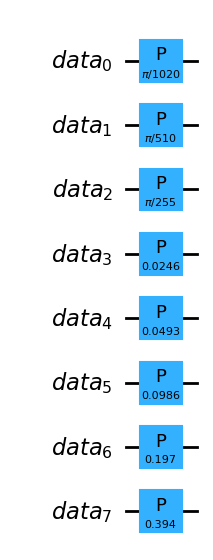

In [2]:
n = 8
q_reg = QuantumRegister(size=n, name="data")
qc = QuantumCircuit( q_reg, name="U_f")

for k in range(n):
    theta = (np.pi/4) * (2**k) / 255
    qc.p(theta, q_reg[k])
    
U_f = qc.to_gate(label="U_f")
    
qc.draw(output="mpl")

###  Selective Phase-Flip Operator: $S_{\Psi_0}$

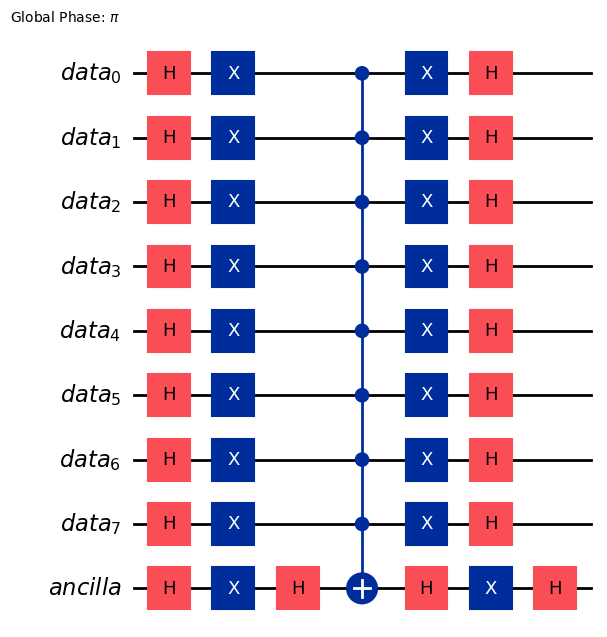

In [3]:
q_reg = QuantumRegister(size=n, name="data")
a_reg = QuantumRegister(size=1, name="ancilla")
qc = QuantumCircuit(q_reg, a_reg, name="S_psi_0")

qc.h(a_reg[0])

# qc.append(U_f.inverse(), q_reg)
qc.h(q_reg)

# implement 2 |0,0> <0,0| - I 
qc.x( q_reg[:] + a_reg[:] )
qc.h( a_reg[:] )
qc.mcx( q_reg, a_reg[0] )
qc.h( a_reg[:] )
qc.x( q_reg[:] + a_reg[:] )

qc.global_phase = np.pi



# qc.append(U_f, q_reg)
qc.h(q_reg)

qc.h(a_reg[0])

S_psi_0 = qc.to_gate()

qc.draw(output="mpl")

### Conditional Oracle Calls: two register unitary operator $CU_f$

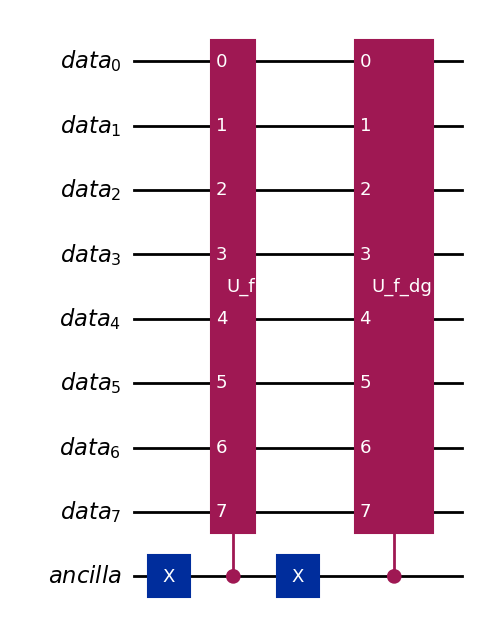

In [20]:
q_reg = QuantumRegister(size=n, name="data")
a_reg = QuantumRegister(size=1, name="ancilla")
qc = QuantumCircuit(q_reg, a_reg, name="CU_f")

# qc.append( U_f.control(ctrl_state=0), [a_reg[0]] + q_reg[:] )
qc.x(a_reg[0])
qc.append( U_f.control(ctrl_state=1), [a_reg[0]] + q_reg[:] )
qc.x(a_reg[0])

qc.append( U_f.inverse().control(ctrl_state=1), [a_reg[0]] + q_reg[:] )

CU_f = qc.to_gate()



qc.draw(output="mpl")

## Iteration operator $Q_{iter}$

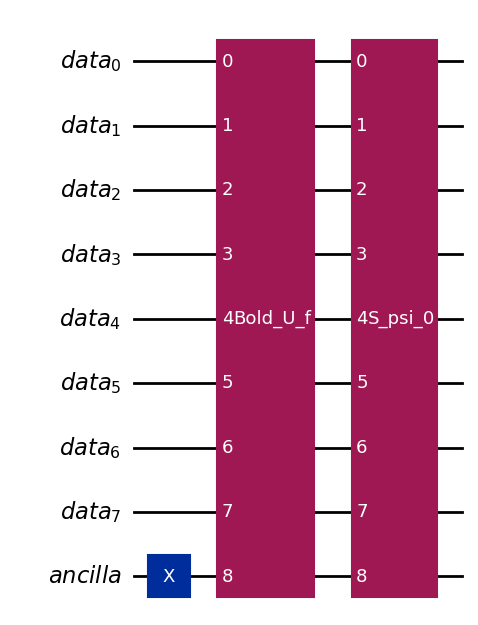

In [5]:
q_reg = QuantumRegister(size=n, name="data")
a_reg = QuantumRegister(size=1, name="ancilla")
qc = QuantumCircuit(q_reg, a_reg, name="Q_iter")

qc.x(a_reg)

qc.append(CU_f, q_reg[:] + a_reg[:])
qc.append(S_psi_0, q_reg[:] + a_reg[:])

Q_iter = qc.to_gate()



qc.draw(output="mpl")

## amplitude amplifier

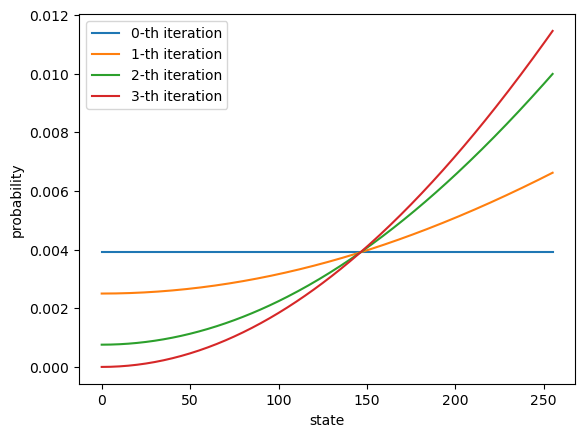

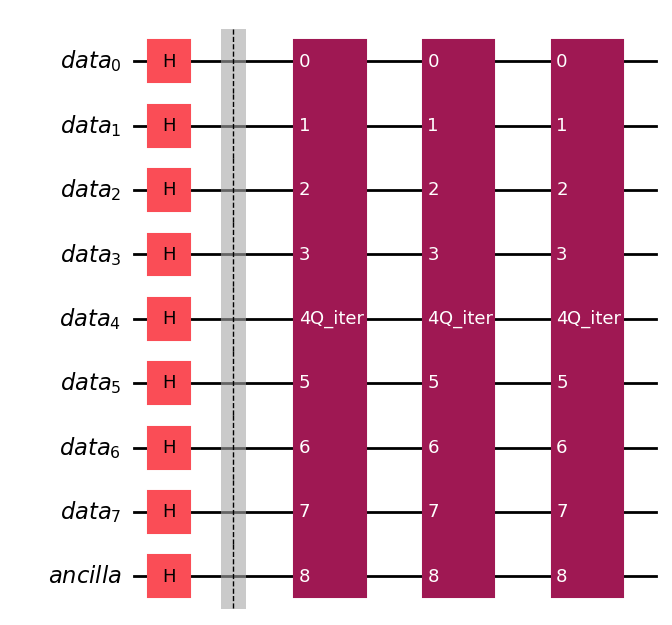

In [39]:
q_reg = QuantumRegister(size=n, name="data")
a_reg = QuantumRegister(size=1, name="ancilla")
# c_reg = ClassicalRegister(size=1, name="classical")


x=[]
for j in range(4):
    
    
    ########### Amplification ################################################
    qc = QuantumCircuit(q_reg, a_reg, name="amplitude amplification")

    qc.h(q_reg)
    qc.h(a_reg[0])
    qc.barrier()  # \psi_0
    for k in range(j):
        qc.append(Q_iter, q_reg[:] + a_reg[:])
    ########### Amplification ################################################

    
    
    psi = Statevector(qc)
    x.append(psi.probabilities()[:256] * 2)

    plt.plot(range(256), x[j], label=f"{j}-th iteration")
    
plt.ylabel('probability')
plt.xlabel('state')
plt.legend()
plt.show()

qc.draw(output="mpl")

# Estimate mean

### Prepare (linear combination of) eigenvectors

$|\Psi_0> = \frac{|\eta_+> + |\eta_->}{\sqrt{2}}$, where 
$$|\eta_{\pm}> = \frac{ e^{\pm i \theta} |\Psi_0 > - |\alpha> }{ i \sqrt{2} \sin(\theta) }$$
and $|\eta_{\pm}>$ are both eigenvectors of $Q_{iter}$
$$Q_{iter} |\eta_{\pm}> = e^{\pm i \theta} |\eta_{\pm}>$$

So using Quantum Phase Estimate (QPE) on $|\Psi_0>$ can get the estimate of $\pm \theta$. 

In [8]:
from qiskit.circuit.library import QFTGate, UnitaryGate

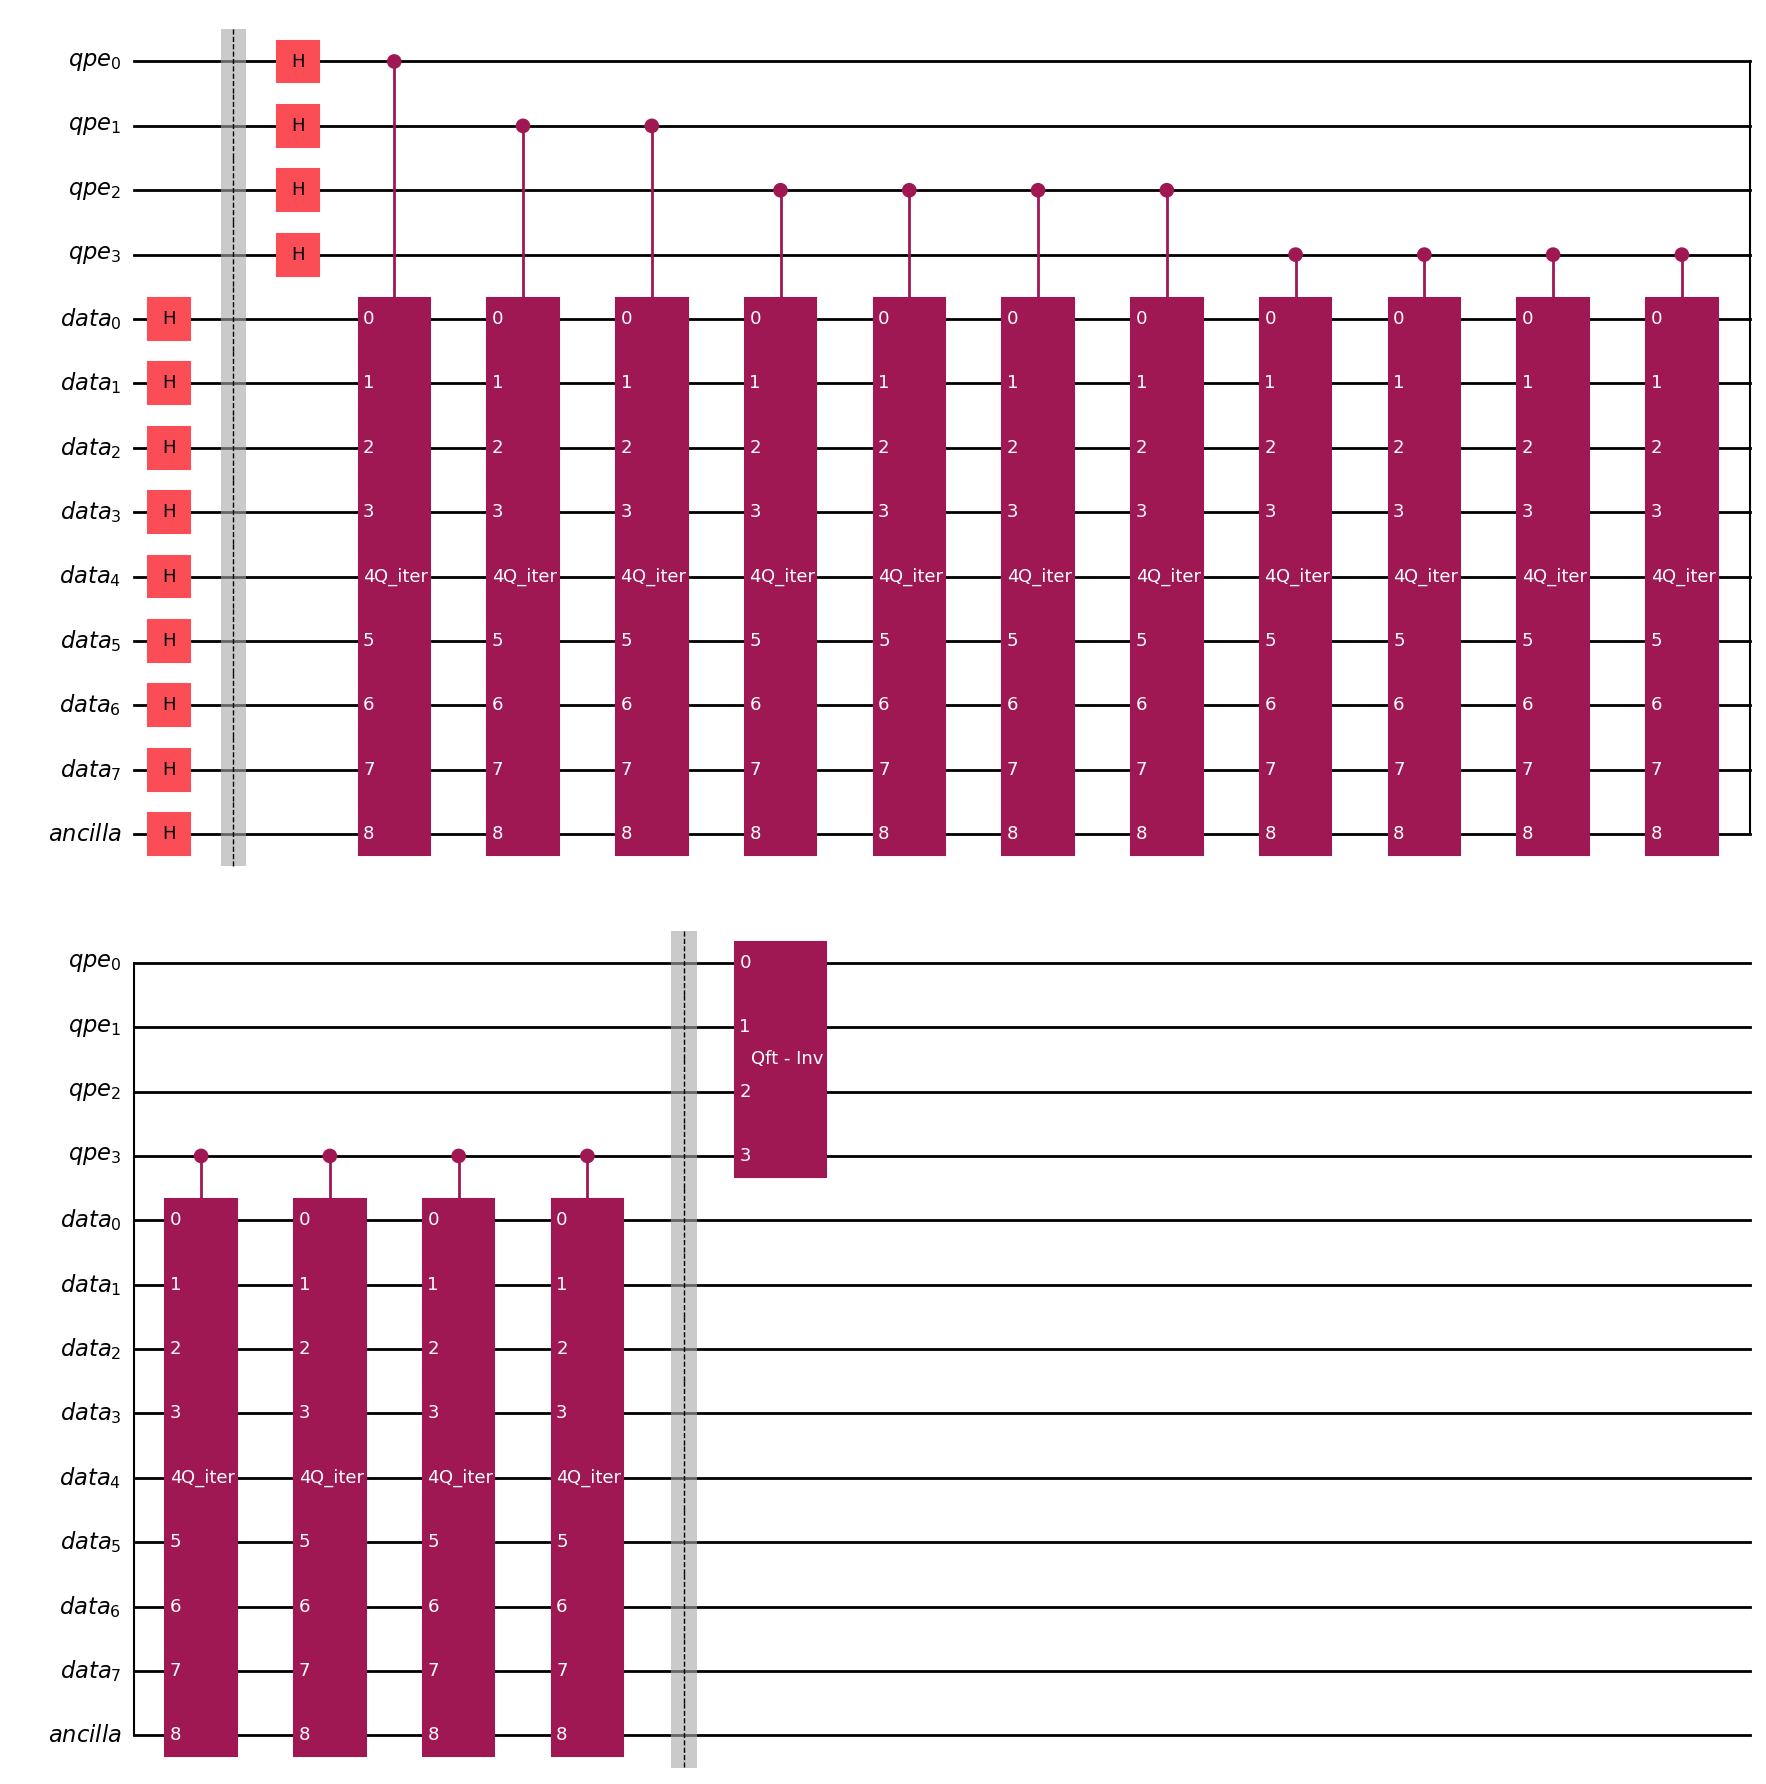

In [13]:
d = 4 # use d digits to estimate
q_reg = QuantumRegister(size=n, name="data")
a_reg = QuantumRegister(size=1, name="ancilla")
qpe_reg = QuantumRegister(size=d, name="qpe")
qc = QuantumCircuit(qpe_reg, q_reg, a_reg, name="QPE on \theta")

# \Psi_0
qc.h(q_reg)
qc.h(a_reg[0])
qc.barrier()

# qpe
qc.h(qpe_reg)
# Q_matrix = Operator(Q_iter).data

CQk = Q_iter.control(1)
for idx, k in enumerate(qpe_reg):
    for j in range(2**idx):
        qc.append(CQk, qargs = [qpe_reg[idx]] + q_reg[:] + a_reg[:])

#     Q_power = UnitaryGate(Q_matrix)
#     CQ_power = Q_power.control(1)
#     qc.append(CQ_power, qargs=[qpe_reg[idx]] + q_reg[:] + a_reg[:])
#     Q_matrix = Q_matrix @ Q_matrix

qc.barrier()
qc.append(QFTGate(num_qubits=d).inverse(annotated=True), qargs = qpe_reg[:])



qc.draw(output="mpl")

Text(0, 0.5, 'probabilities')

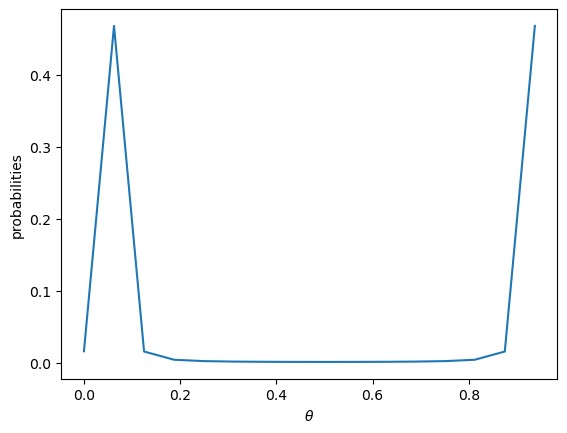

In [14]:
theta_range = np.linspace(0.0, 1.0, num=2**d, endpoint=False)
output_distribution_for_theta = np.sum(Statevector(qc).probabilities().reshape(512, 2**d), axis=0) # marginal probability distribution for the first d qubits

plt.plot(theta_range, output_distribution_for_theta)
plt.xlabel(r"$\theta$")
plt.ylabel(f"probabilities")

In [15]:
qpe_thetas = np.argsort(output_distribution_for_theta)[-1:][::-1]
qpe_thetas

array([1], dtype=int64)

In [16]:
output_distribution_for_theta

array([0.01567921, 0.4675722 , 0.01527672, 0.00383359, 0.00193256,
       0.00127928, 0.00099197, 0.00086203, 0.00082407, 0.00086203,
       0.00099197, 0.00127928, 0.00193256, 0.00383359, 0.01527672,
       0.4675722 ])

## Estimate of theta $\hat{\theta}$

In [17]:
theta_hat = (qpe_thetas[0]) * (2*np.pi / 2**d)
theta_hat

0.39269908169872414

So the estimate mean of $\{ \cos( \frac{2 \pi}{4} \times \frac{k}{255} ) \}_{k=0 \sim 255}$ is $\cos(\hat{\theta})$. 

In [18]:
np.cos(theta_hat)

0.9238795325112867